In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

In [2]:
car_df = pd.read_csv("car.csv")
car_df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [3]:
car_df.shape

(892, 6)

In [4]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [5]:
car_df.isnull().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [6]:
car_df.duplicated().sum()

94

In [7]:
counts = car_df['company'].value_counts()
counts

Maruti        235
Hyundai       145
Mahindra      100
Tata           74
Honda          61
Toyota         39
Chevrolet      35
Renault        34
Ford           31
Volkswagen     20
Skoda          13
Audi           11
Datsun          8
Mini            8
BMW             8
Nissan          6
Commercial      6
Mercedes        6
Mitsubishi      6
Force           4
Fiat            4
tata            3
Hindustan       3
I               3
MARUTI          2
urgent          2
Used            2
Jaguar          2
Sale            2
Well            1
Any             1
TATA            1
sell            1
scratch         1
9               1
7               1
all             1
Land            1
2012            1
i               1
Volvo           1
very            1
Jeep            1
Swift           1
URJENT          1
selling         1
Yamaha          1
Tara            1
Name: company, dtype: int64

In [8]:
car_df['company'] = car_df['company'].str.strip()
car_df['company'] = car_df['company'].str.title()

In [9]:
car_df = car_df[car_df['company'].str.isalpha()]
valid_companies = counts[counts > 5].index

In [10]:
car_df = car_df[car_df['company'].isin(valid_companies)]
car_df['company'].value_counts()

Maruti        237
Hyundai       145
Mahindra      100
Tata           78
Honda          61
Toyota         39
Chevrolet      35
Renault        34
Ford           31
Volkswagen     20
Skoda          13
Audi           11
Mini            8
Datsun          8
Mitsubishi      6
Nissan          6
Commercial      6
Mercedes        6
Name: company, dtype: int64

In [11]:
car_df.duplicated().sum()

90

In [12]:
car_df = car_df.drop_duplicates()

In [13]:
car_df.duplicated().sum()

0

In [14]:
car_df['name'] = car_df['name'].str[:3]

In [15]:
car_df['year'] = pd.to_numeric(car_df['year'], errors='coerce')

In [16]:
car_df['Price'] = car_df['Price'].str.replace(',', '')
car_df['Price'] = pd.to_numeric(car_df['Price'], errors='coerce')

In [17]:
car_df['kms_driven'] = car_df['kms_driven'].str.split().str[0]
car_df['kms_driven'] = car_df['kms_driven'].str.replace(',', '')
car_df['kms_driven'] = pd.to_numeric(car_df['kms_driven'], errors='coerce')

In [18]:
car_df.isnull().sum()

name           0
company        0
year          27
Price         28
kms_driven    29
fuel_type     30
dtype: int64

In [19]:
car_df = car_df.dropna(subset=['Price'])

In [20]:
car_df['year'].fillna(car_df['year'].median(), inplace=True)
car_df['kms_driven'].fillna(car_df['kms_driven'].median(), inplace=True)
car_df['fuel_type'].fillna(car_df['fuel_type'].mode()[0], inplace=True)
car_df.isnull().sum()

name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64

In [21]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 726 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        726 non-null    object 
 1   company     726 non-null    object 
 2   year        726 non-null    float64
 3   Price       726 non-null    float64
 4   kms_driven  726 non-null    float64
 5   fuel_type   726 non-null    object 
dtypes: float64(3), object(3)
memory usage: 39.7+ KB


In [22]:
car_df.describe()

,year,Price,kms_driven
count,726.000000,7.260000e+02,726.000000
mean,2012.403581,3.825653e+05,46526.840220
std,4.008396,4.522925e+05,33723.080058
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.650000e+05,28000.000000
50%,2013.000000,2.850000e+05,42000.000000
75%,2015.000000,4.650000e+05,57692.250000
max,2019.000000,8.500003e+06,400000.000000


In [23]:
car_df[car_df['kms_driven']>200000]

,name,company,year,Price,kms_driven,fuel_type
362,Hon,Honda,2010.0,240000.0,400000.0,Petrol


In [24]:
car_df = car_df.drop(362)

In [25]:
car_df.sort_values('Price', ascending=False).head(10)

,name,company,year,Price,kms_driven,fuel_type
562,Mah,Mahindra,2014.0,8500003.0,45000.0,Diesel
719,Aud,Audi,2015.0,3100000.0,12516.0,Petrol
838,For,Ford,2019.0,2900000.0,9000.0,Diesel
668,Aud,Audi,2014.0,2390000.0,34000.0,Diesel
231,Mer,Mercedes,2015.0,2000000.0,20000.0,Diesel
678,Aud,Audi,2016.0,1900000.0,44000.0,Diesel
79,Min,Mini,2013.0,1891111.0,13500.0,Petrol
249,Min,Mini,2013.0,1891111.0,13000.0,Petrol
73,Min,Mini,2013.0,1891111.0,13000.0,Petrol
694,Mit,Mitsubishi,2015.0,1725000.0,37000.0,Diesel


In [26]:
car_df = car_df.drop(562)

In [27]:
car_df.describe()

,year,Price,kms_driven
count,724.000000,7.240000e+02,724.000000
mean,2012.404696,3.715503e+05,46040.726519
std,4.012502,3.374118e+05,31102.088436
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.650000e+05,28000.000000
50%,2013.000000,2.850000e+05,42000.000000
75%,2015.000000,4.650000e+05,57230.750000
max,2019.000000,3.100000e+06,200000.000000


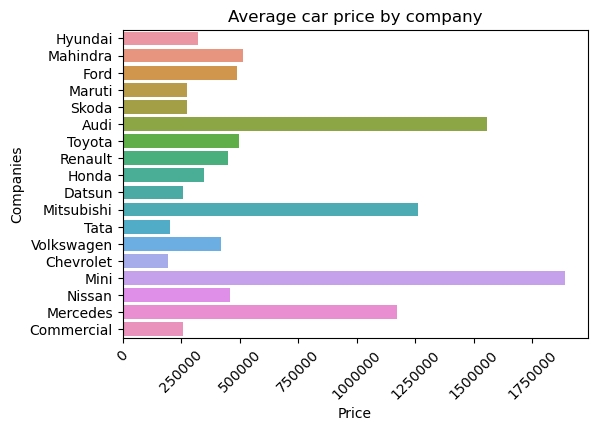

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(data = car_df, y = 'company', x = 'Price',estimator=np.mean, errorbar=None)
plt.title("Average car price by company")
plt.xlabel('Price')
plt.ylabel("Companies")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

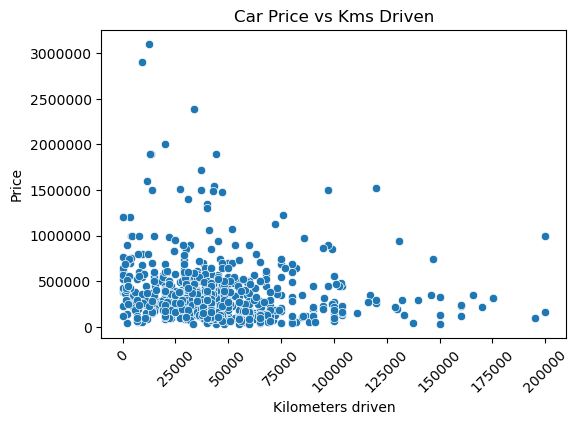

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(data = car_df, x = 'kms_driven', y = 'Price')
plt.title("Car Price vs Kms Driven")
plt.xlabel('Kilometers driven')
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [30]:
car_df['car_age'] = 2019 - car_df['year']

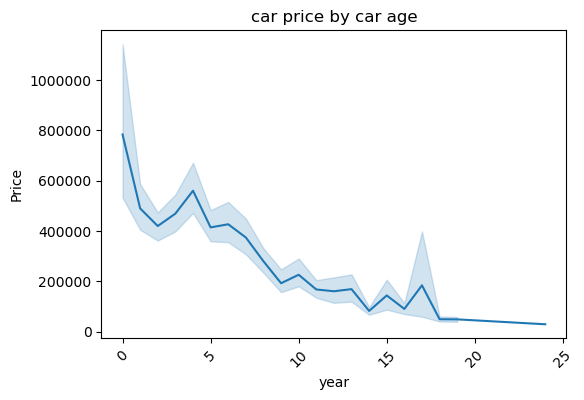

In [31]:
plt.figure(figsize=(6,4))
sns.lineplot(data = car_df, x = 'car_age', y = 'Price')
plt.title("car price by car age")
plt.xlabel('year')
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

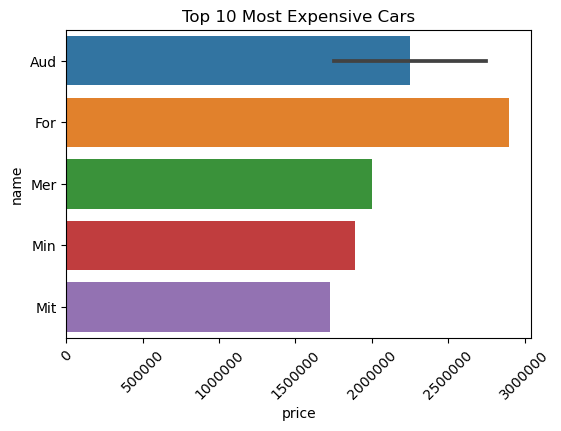

In [32]:
top_10_car = car_df.sort_values('Price', ascending = False).head(10)

plt.figure(figsize=(6,4))
sns.barplot(data = top_10_car, y = 'name', x = 'Price')
plt.title("Top 10 Most Expensive Cars")
plt.xlabel('price')
plt.ylabel("name")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

C:\Users\aditya\AppData\Local\Temp\ipykernel_102920\3299563429.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(car_df.corr(),annot=True, cmap='coolwarm')


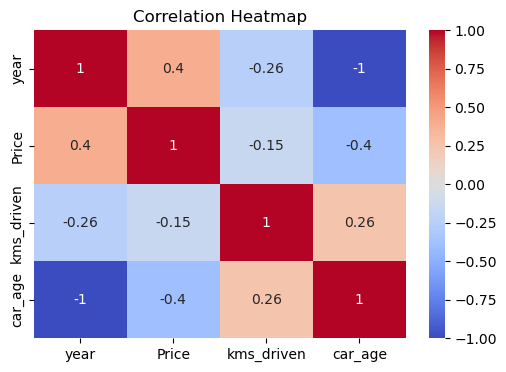

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap(car_df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [34]:
X = car_df[['name','company','year','fuel_type','kms_driven','car_age']]
y = car_df['Price']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


In [36]:
cat_cols = ['name','company','fuel_type']

column_trans = ColumnTransformer(
    [('encoder', OneHotEncoder(sparse_output=False, drop='first',handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

In [37]:
pipe = make_pipeline(column_trans, LinearRegression())
pipe.fit(X_train, y_train)

y_pred_lr = pipe.predict(X_test)

In [38]:
score = r2_score(y_test, y_pred_lr)
print(score)

0.5258385239127066


In [39]:
new_car = pd.DataFrame(
    [['Maruti Swift', 'Maruti', 2019, 10000, 'Petrol', 2026-2019]],
    columns=['name', 'company', 'year', 'kms_driven', 'fuel_type', 'car_age']
)

price = pipe.predict(new_car)[0]
print("Predicted Price:", round(price))

Predicted Price: 881465


C:\Users\aditya\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [40]:
pickle.dump(pipe, open('LinearRegressionModel.pkl', 'wb'))
print("Model Saved Successfully")

Model Saved Successfully
